## Recurrent Neural Network (RNN) / LSTM for Time Series Prediction

This notebook demonstrates a basic implementation of a Long Short-Term Memory (LSTM) network, a type of Recurrent Neural Network (RNN), for time series prediction. We'll generate synthetic data, prepare it, build a simple LSTM model, and train it.

### 1. Import Libraries

We'll start by importing the necessary libraries, including TensorFlow/Keras for building the neural network and NumPy for numerical operations.

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import matplotlib.pyplot as plt

print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.19.0


### 2. Generate Synthetic Time Series Data

For demonstration purposes, we'll create a simple sine wave time series. This will serve as our dataset to train the LSTM.

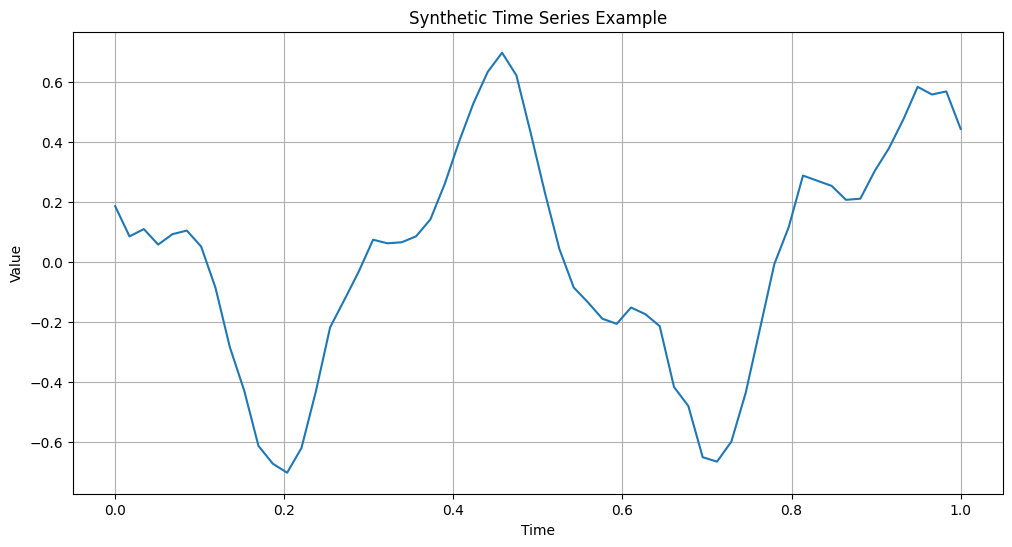

In [2]:
def generate_time_series(batch_size, n_steps):
    freq1, freq2, offsets1, offsets2 = np.random.rand(4, batch_size, 1)
    time = np.linspace(0, 1, n_steps)
    series = 0.5 * np.sin((time - offsets1) * (freq1 * 10 + 10))  #   wave 1
    series += 0.2 * np.sin((time - offsets2) * (freq2 * 20 + 20)) # + wave 2
    series += 0.1 * (np.random.rand(batch_size, n_steps) - 0.5)   # + noise
    return series[..., np.newaxis]

# Generate a single time series for visualization
n_steps = 50
time_series = generate_time_series(1, n_steps + 10)
time = np.linspace(0, 1, n_steps + 10)

plt.figure(figsize=(12, 6))
plt.plot(time, time_series[0, :, 0])
plt.title("Synthetic Time Series Example")
plt.xlabel("Time")
plt.ylabel("Value")
plt.grid(True)
plt.show()

### 3. Prepare Data for LSTM

LSTMs typically take sequences as input. For time series prediction, we'll create input sequences (`X`) and corresponding target values (`y`). Each `X` will be a sequence of `n_steps` values, and `y` will be the value immediately following that sequence.

Here, we'll split our generated time series into training, validation, and test sets. We'll also define a function to create sequences for the LSTM.

In [3]:
n_steps = 50
n_features = 1 # Each time point is a single value

series = generate_time_series(10000, n_steps + 1)

X_train, y_train = series[:7000, :n_steps], series[:7000, -1]
X_valid, y_valid = series[7000:9000, :n_steps], series[7000:9000, -1]
X_test, y_test = series[9000:, :n_steps], series[9000:, -1]

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_valid shape: {X_valid.shape}")
print(f"y_valid shape: {y_valid.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (7000, 50, 1)
y_train shape: (7000, 1)
X_valid shape: (2000, 50, 1)
y_valid shape: (2000, 1)
X_test shape: (1000, 50, 1)
y_test shape: (1000, 1)


### 4. Build the LSTM Model

We'll define a simple Sequential Keras model with one LSTM layer and a Dense output layer. The `input_shape` for the LSTM layer should be `(n_steps, n_features)`.

In [4]:
model = Sequential([
    LSTM(units=20, activation='relu', input_shape=(n_steps, n_features)),
    Dense(units=n_features)
])

model.compile(optimizer='adam', loss='mse')

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 20)             │         1,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,781 (6.96 KB)

 Trainable params: 1,781 (6.96 KB)

 Non-trainable params: 0 (0.00 B)

### 5. Train the Model

Now we'll train the LSTM model using our prepared data. We'll use a validation set to monitor performance during training.

Epoch 1/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - loss: 0.0758 - val_loss: 0.0523
Epoch 2/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0268 - val_loss: 0.0169
Epoch 3/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.0154 - val_loss: 0.0134
Epoch 4/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.0126 - val_loss: 0.0104
Epoch 5/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.0102 - val_loss: 0.0096
Epoch 6/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0078 - val_loss: 0.0067
Epoch 7/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - loss: 0.0063 - val_loss: 0.0054
Epoch 8/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.0061 - val_loss: 0.0054
Epoch 9/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0060 - val_loss: 0.0050
Epoch 10/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.0056 - val_loss: 0.0049


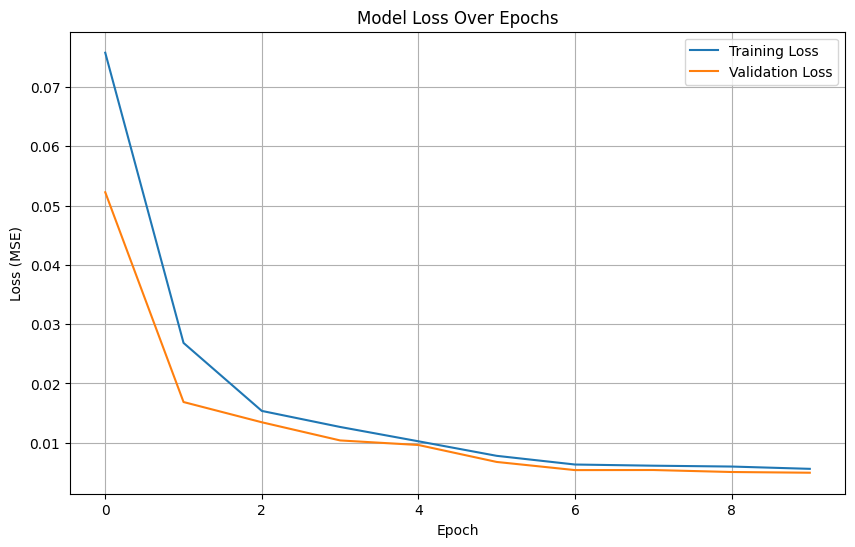

In [5]:
history = model.fit(X_train, y_train, epochs=10, validation_data=(X_valid, y_valid))

# Plot training history
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

### 6. Evaluate and Make Predictions

Finally, let's evaluate the model on the test set and make some predictions to see how well it performs.

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0049
Test Mean Squared Error (MSE): 0.0049
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


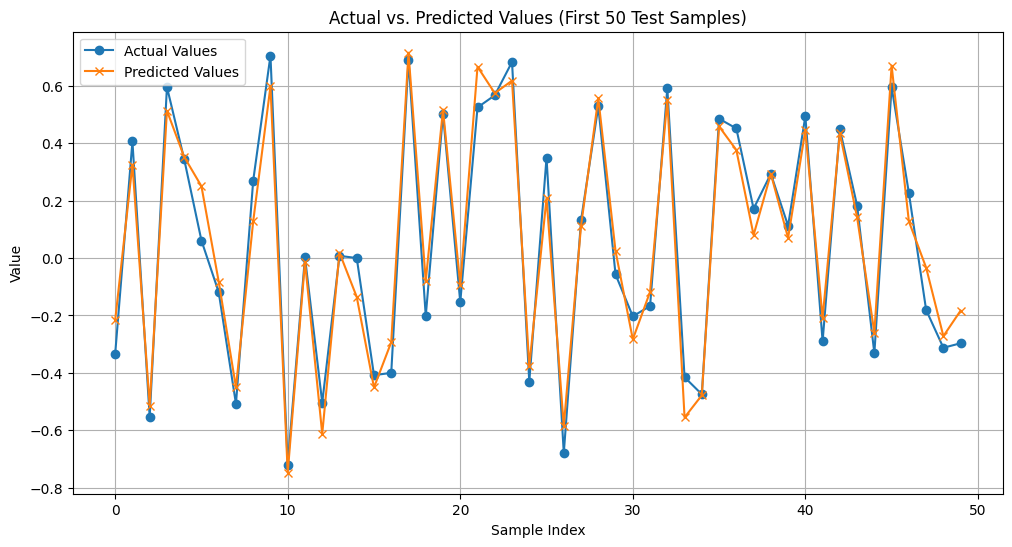

In [6]:
mse = model.evaluate(X_test, y_test)
print(f"Test Mean Squared Error (MSE): {mse:.4f}")

# Make predictions
y_pred = model.predict(X_test)

# Plot some predictions vs actual values (e.g., first 50 test samples)
plt.figure(figsize=(12, 6))
plt.plot(y_test[:50], label='Actual Values', marker='o')
plt.plot(y_pred[:50], label='Predicted Values', marker='x')
plt.title('Actual vs. Predicted Values (First 50 Test Samples)')
plt.xlabel('Sample Index')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()